<div dir="rtl">

# DBSCAN بخش ۱: مدل پایه

در این نوت‌بوک آگهی‌ها رو فقط با دو ویژگی مختصات UTM و قیمت قابل تبدیل با DBSCAN خوشه‌بندی می‌کنیم. این مدل پایه با تنظیمات پیش‌ فرض است تا بعدا ببینیم تنظیم هایپرپارامترها چه فرقی ایجاد می‌کنه


</div>

<div dir="rtl">

## ۱. خواندن داده و ساخت قیمت یکپارچه

قیمت یکپارچه دقیقا مثل بخش K-means ساخته شده تا هر دو بخش روی یک تعریف کار کنن برای آگهی فروش قیمت فروش و برای رهن کامل مبلغ رهن و برای بقیه اجاره‌ها رهن تبدیل‌شده.
فقط آگهی‌هایی میمونن که هم مختصات و هم قیمت دارد. DBSCAN با مقدار خالی کار نمی‌کند و پر کردن مکان یا قیمت با میانگین ملک ساختگی درست می‌کنه

</div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
df = pd.read_parquet("../data/Divar_cleaned.parquet")

is_sell = df["cat2_slug"].str.contains("sell", na=False).fillna(False).astype(bool)
is_full_credit = (df["inferred_full_credit"] == True).fillna(False).astype(bool)

df["unified_price"] = np.select(
    [is_sell, is_full_credit],
    [df["price_value"], df["transformable_credit"]],
    default=df["transformed_credit"],
)
df["unified_price"] = df["unified_price"].replace(0, np.nan)

features = ["location_utm_x", "location_utm_y", "unified_price"]
data = df[features + ["city_slug", "cat2_slug"]].dropna(subset=features).copy()

print(f"kol agahi ha: {len(df):,}")
print(f"agahi haye ba UTM va gheymat: {len(data):,} ({len(data) / len(df) * 100:.1f}%)")

kol agahi ha: 999,997
agahi haye ba UTM va gheymat: 441,101 (44.1%)


<div dir="rtl">

## ۲. تمیزکاری و مقیاس‌بندی

قیمت‌هایی که همه رقم‌هاشون یکیه مثل ۹۹۹۹۹۹۹ حذف شدن. بعد از قیمت لگاریتم گرفتیم و ۱ درصد بالا پایین رو کنار گذاشتیم چون DBSCAN به نقطه‌های پرت خیلی حساسه 
در آخر با StandardScaler هر سه ویژگی را هم‌ مقیاس کردم. مختصات به متر است و صدها هزاره ولی لگاریتم قیمت حدود ۲۰ است. بدون این کار فاصله‌ها رو فقط مختصات تعیین می‌کرد.

</div>

In [2]:
def is_fake_price(price):
    digits = str(int(price))
    return len(digits) >= 6 and len(set(digits)) == 1

before = len(data)
data = data[~data["unified_price"].apply(is_fake_price)]
print(f"gheymat haye alaki hazf shode: {before - len(data):,}")

data["log_price"] = np.log1p(data["unified_price"])
low, high = data["log_price"].quantile([0.01, 0.99])

before = len(data)
data = data[data["log_price"].between(low, high)].copy()
print(f"part haye hazf shode: {before - len(data):,}")

X = data[["location_utm_x", "location_utm_y", "log_price"]]
X_scaled = StandardScaler().fit_transform(X)

print(f"dade nahayi baraye DBSCAN: {len(data):,}")
data[["location_utm_x", "location_utm_y", "unified_price"]].describe().round(0)

gheymat haye alaki hazf shode: 7,105
part haye hazf shode: 8,525
dade nahayi baraye DBSCAN: 425,471


,location_utm_x,location_utm_y,unified_price
count,425471.0,425471.0,4.254710e+05
mean,552940.0,3890508.0,4.421169e+09
std,272660.0,247199.0,6.605826e+09
min,-90946.0,2803746.0,2.800000e+06
25%,482813.0,3909298.0,1.000000e+09
50%,530564.0,3953770.0,2.350000e+09
75%,568186.0,4037365.0,5.000000e+09
max,1660176.0,4407134.0,6.000000e+10


<div dir="rtl">

## ۳. آیا می‌شود روی کل داده اجرا کرد؟

DBSCAN برای هر نقطه همه همسایه‌ هاش رو توی ر حافظه نگه مییداره. برای ۲ هزار نقطه تصادفی تعداد همسایه هارو شمردیم و رم لازم برای کل داده را تخمین زدیم:

| eps | میانگین همسایه | رم لازم |
|---|---|---|
| ۰.۰۵ | ۶۰۸ | ۲ گیگ |
| ۰.۱ | ۲,۲۳۰ | ۸ گیگ |
| ۰.۲ | ۸,۲۱۹ | ۲۸ گیگ |
| ۰.۳ | ۱۵,۱۱۱ | ۵۱ گیگ |
| ۰.۵ | ۳۰,۴۴۱ | ۱۰۴ گیگ |

روی کل داده فقط eps های خیلی کوچک اجرا میشن که صدها خوشه ریز می‌سازه. برای رسیدن به حدود ۳ خوشه epsبزرگ‌تر لازم است که ده‌ها گیگ رم می‌خواد که ما نداریم 

</div>

In [3]:
from sklearn.neighbors import KDTree
tree = KDTree(X_scaled)
rng = np.random.RandomState(42)
idx = rng.choice(len(X_scaled), 2000, replace=False)

for eps in [0.05, 0.1, 0.2, 0.3, 0.5]:
    counts = tree.query_radius(X_scaled[idx], r=eps, count_only=True)
    ram_gb = counts.mean() * len(X_scaled) * 8 / 1e9
    print(f"eps={eps}: miangin hamsaye {counts.mean():,.0f} | RAM takhmini {ram_gb:,.1f} GB")

eps=0.05: miangin hamsaye 608 | RAM takhmini 2.1 GB
eps=0.1: miangin hamsaye 2,230 | RAM takhmini 7.6 GB
eps=0.2: miangin hamsaye 8,219 | RAM takhmini 28.0 GB
eps=0.3: miangin hamsaye 15,111 | RAM takhmini 51.4 GB
eps=0.5: miangin hamsaye 30,441 | RAM takhmini 103.6 GB


<div dir="rtl">

## ۴. نمونه‌گیری

به همین دلیل DBSCAN رو روی یک نمونه تصادفی ۵۰ هزارتایی اجرا می‌کنیم. رم لازم تقریبا با مجذور تعداد نقطه‌های ما کم می‌شه و با این نمونه حدود ۷۰ برابر کمتر می‌شه و اوکیه
تمیزکاری و مقیاس‌بندی روی کل داده انجام شده و نمونه فقط برای خود DBSCAN است. جدول نشان میدهد سهم هر دسته در نمونه تقریبا مثل کل داده است پس نمونه نماینده خوبی است.

</div>

In [4]:
rng = np.random.RandomState(42)
pos = rng.choice(len(data), 50_000, replace=False)
sample = data.iloc[pos].copy()
X_sample = X_scaled[pos]

print(f"nemoone: {len(sample):,} az {len(data):,} ({len(sample) / len(data) * 100:.1f}%)")

compare = pd.DataFrame({
    "kol_dade": data["cat2_slug"].value_counts(normalize=True).round(3),
    "nemoone": sample["cat2_slug"].value_counts(normalize=True).round(3),
})
compare

nemoone: 50,000 az 425,471 (11.8%)


,kol_dade,nemoone
cat2_slug,,
residential-sell,0.762,0.763
residential-rent,0.175,0.175
commercial-sell,0.043,0.042
commercial-rent,0.02,0.02


<div dir="rtl">

## ۵. اجرای DBSCAN پایه

از مقدارهای پیش‌فرض کتابخانه استفاده کردیم یعنی eps برابر ۰.۵ و min_samples برابر ۵. نقطه‌هایی که DBSCAN نمی‌تواند در هیچ خوشه‌ای بگذارد برچسب -1 می‌گیرند که همان Noise است.

</div>

In [5]:
import time
start = time.time()
model = DBSCAN(eps=0.5, min_samples=5)
sample["cluster"] = model.fit_predict(X_sample)
print(f"zaman ejra: {time.time() - start:.1f} sanie")

n_clusters = sample["cluster"].nunique() - (1 if -1 in sample["cluster"].values else 0)
n_noise = (sample["cluster"] == -1).sum()

print(f"tedad cluster: {n_clusters}")
print(f"tedad noise: {n_noise:,}")
print(f"darsad noise: {n_noise / len(sample) * 100:.2f}%")

zaman ejra: 3.9 sanie
tedad cluster: 9
tedad noise: 56
darsad noise: 0.11%


<div dir="rtl">

## ۶. مشخصات خوشه‌ها و نمودار

برای هر خوشه تعداد و میانه قیمت و پرتکرارترین شهر رو حساب کردیم تا بفهمیم هر خوشه عملا کدوم اگهیه


</div>

In [6]:
summary = sample.groupby("cluster").agg(
    tedad=("cluster", "size"),
    median_gheymat=("unified_price", "median"),
    shahr_asli=("city_slug", lambda s: s.value_counts().index[0]),
    sahm_shahr_asli=("city_slug", lambda s: s.value_counts(normalize=True).iloc[0] * 100),
)

summary["darsad"] = (summary["tedad"] / len(sample) * 100).round(2)
summary["median_gheymat"] = (summary["median_gheymat"] / 1e9).round(2)
summary["sahm_shahr_asli"] = summary["sahm_shahr_asli"].round(1)

summary = summary.rename(columns={"median_gheymat": "median_gheymat (milyard)"})
summary.sort_values("tedad", ascending=False)

,tedad,median_gheymat (milyard),shahr_asli,sahm_shahr_asli,darsad
cluster,,,,,
0,49560,2.35,tehran,23.8,99.12
1,261,1.55,zahedan,81.2,0.52
-1,56,0.02,isfahan,8.9,0.11
2,46,2.35,chabahar,95.7,0.09
3,35,0.65,zabol,85.7,0.07
4,19,1.00,saravan,100.0,0.04
8,7,0.01,ahvaz,57.1,0.01
6,6,2.20,tabas,100.0,0.01
5,5,0.00,arak,20.0,0.01


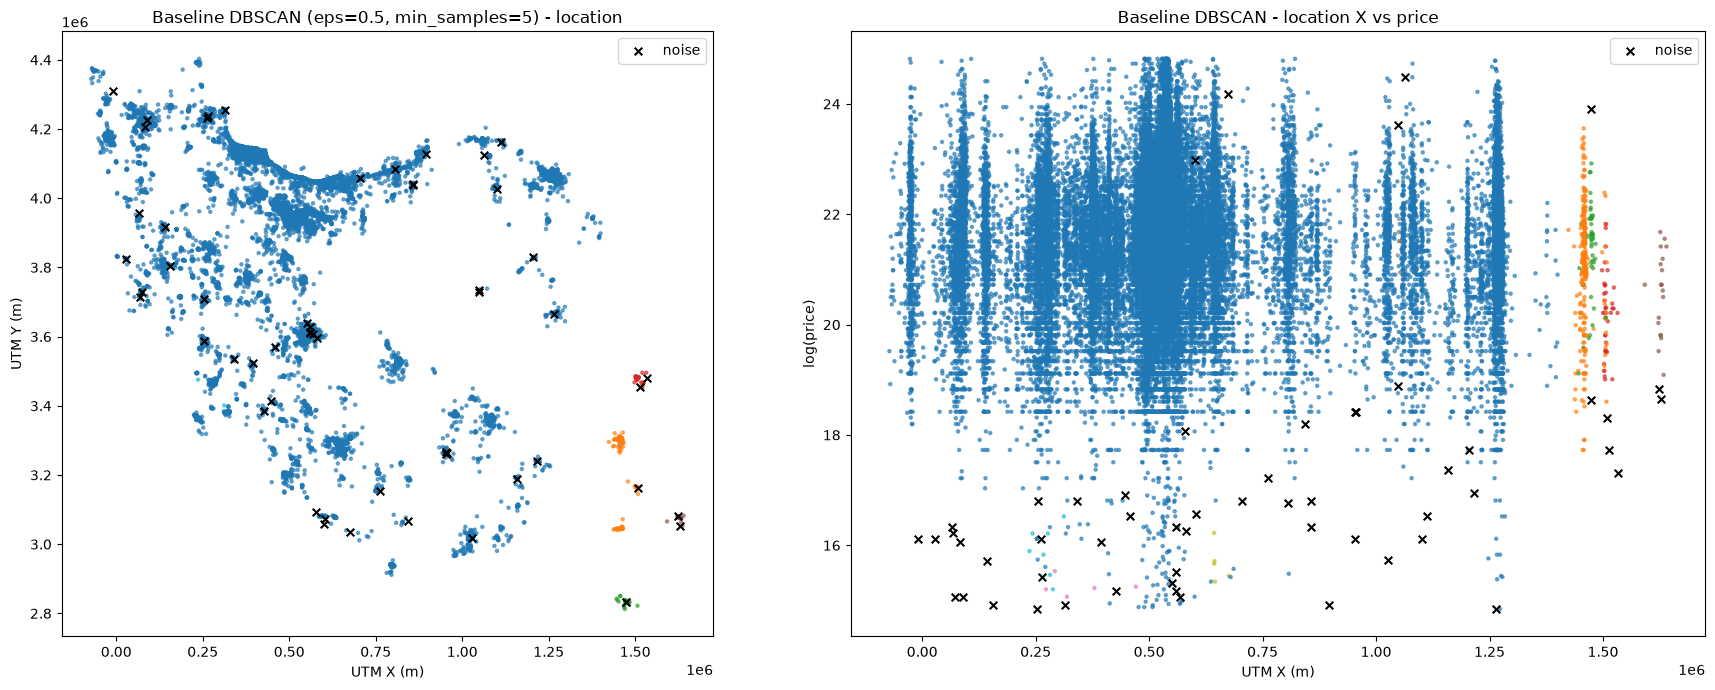

In [7]:
noise = sample[sample["cluster"] == -1]
clustered = sample[sample["cluster"] != -1]
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].scatter(clustered["location_utm_x"], clustered["location_utm_y"],
                c=clustered["cluster"], cmap="tab10", s=5, alpha=0.6)
axes[0].scatter(noise["location_utm_x"], noise["location_utm_y"],
                c="black", marker="x", s=30, label="noise")
axes[0].set_title("Baseline DBSCAN (eps=0.5, min_samples=5) - location")
axes[0].set_xlabel("UTM X (m)")
axes[0].set_ylabel("UTM Y (m)")
axes[0].set_aspect("equal")
axes[0].legend()

axes[1].scatter(clustered["location_utm_x"], clustered["log_price"],
                c=clustered["cluster"], cmap="tab10", s=5, alpha=0.6)
axes[1].scatter(noise["location_utm_x"], noise["log_price"],
                c="black", marker="x", s=30, label="noise")
axes[1].set_title("Baseline DBSCAN - location X vs price")
axes[1].set_xlabel("UTM X (m)")
axes[1].set_ylabel("log(price)")
axes[1].legend()

plt.tight_layout()
plt.show()

<div dir="rtl">

## نتیجه مدل پایه

مدل پایه ۹ خوشه و فقط ۵۶ نقطه Noise ساخت که ۰.۱۱ درصد میشه. ولی یکی از خوشه‌ها ۹۹ درصد کل داده هارو داره. یعنی با eps پیش‌فرض تقریبا همه ایران به هم وصل شده و خوشه‌بندی معناداری انجام نشده.

بقیه خوشه‌ها دو نوع‌ان هستن. بعضی شهرهای دورافتاده جنوب شرق هستند مثل زاهدان و زابل و چابهار که فقط به خاطر فاصله از بقیه ایران جدا شدن. بعضی هم چند آگهی خیلی ارزونند که به خاطر قیمت جدا شده‌اند.

پس تنظیمات پیش‌فرض برای این داده مناسب نیست و باید eps و min_samples را تنظیم کنیم.

</div>